In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Polynomail_regression-Prac.csv to Polynomail_regression-Prac.csv


In [4]:
#Read exel file
df = pd.read_csv('Polynomail_regression-Prac.csv')
# Display first  rows
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [5]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None

Summary Statistics:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [6]:
df.shape

(10, 3)

In [7]:
df.isnull().any()

,0
Position,False
Level,False
Salary,False


In [8]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


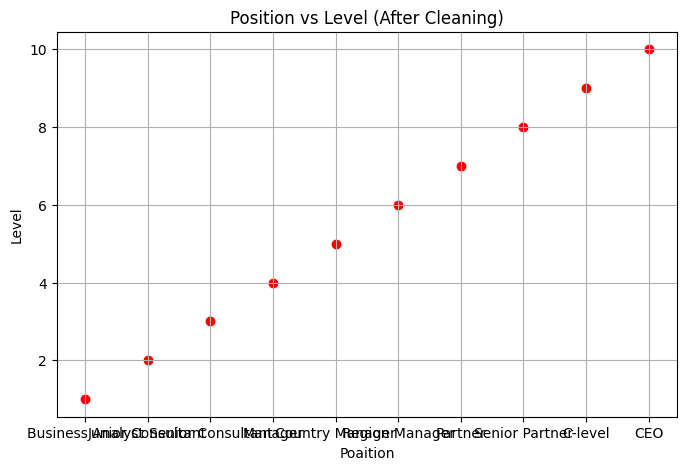

In [9]:
# Visualization to verify
plt.figure(figsize=(8,5))
sns.scatterplot(x='Position', y='Level', data=df, color='red', s=60)
plt.title("Position vs Level (After Cleaning)")
plt.xlabel("Poaition")
plt.ylabel("Level")
plt.grid(True)
plt.show()

In [15]:
#To predict employee salary based on position level using Polynomial Regression.
# Independent and dependent variables
X = df[['Salary']].values
y = df['Level'].values

In [16]:
# Step 3: Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)



In [17]:
# Step 4: Polynomial Regression (Degree 2 and 3)

# Degree 2 (Quadratic)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [18]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [19]:
# Step 5: Evaluate Models
print("\nModel Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")



Model Performance Comparison:
Linear Regression R² Score: 0.6690
Polynomial (Degree 2) R² Score: 0.9093
Polynomial (Degree 3) R² Score: 0.9769


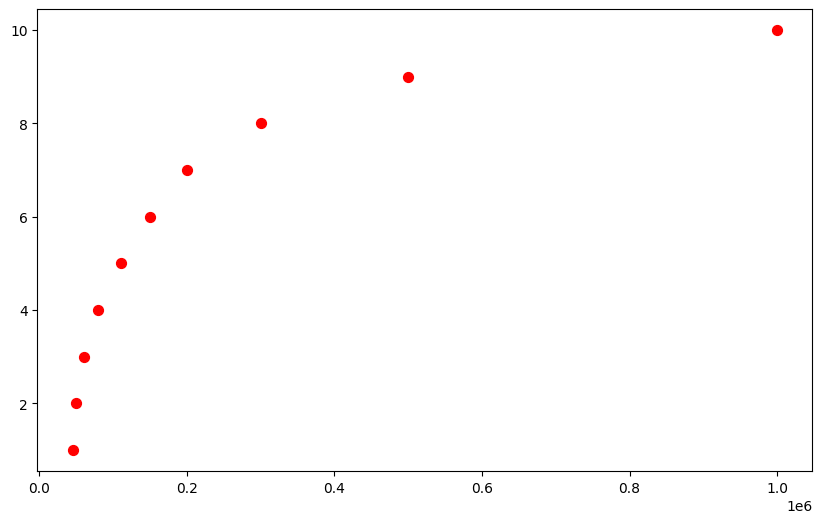

In [20]:
plt.figure(figsize=(10,6))

# Scatter plot of original data
plt.scatter(X, y, color='red', s=50, label='Actual Data')


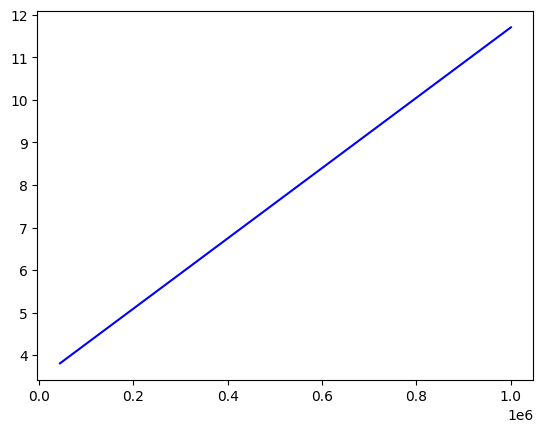

In [21]:
# Linear Regression line
plt.plot(X, y_pred_linear, color='blue', label=f'Linear Fit (R²={r2_linear:.3f})')


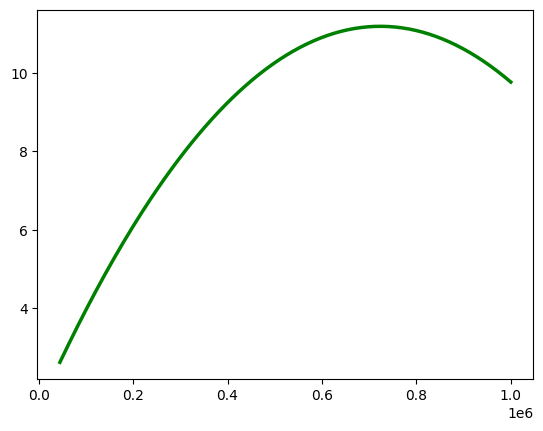

In [22]:
# Polynomial (Degree 2) curve
X_grid = np.linspace(min(X), max(X), 200).reshape(-1,1)
plt.plot(X_grid, poly_reg2.predict(poly2.transform(X_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

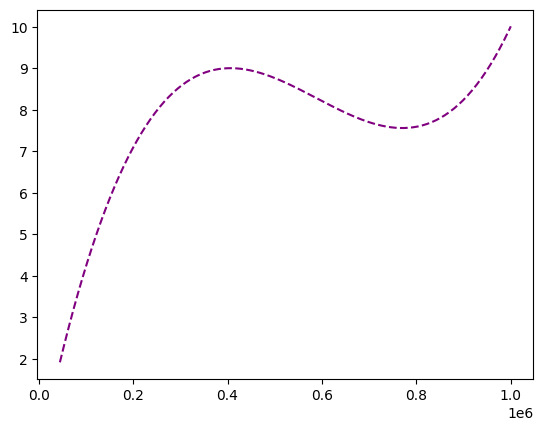

In [23]:
# Polynomial (Degree 3) curve
plt.plot(X_grid, poly_reg3.predict(poly3.transform(X_grid)), color='purple', linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R²={r2_poly3:.3f})')

In [25]:
# Step 7: Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [ 0.00000000e+00  2.69568237e-05 -1.86278446e-11]
Degree 2 Intercept: 1.436424325352199
Degree 2 MSE: 0.7482

Degree 3 Coefficients: [ 0.00000000e+00  5.61921043e-05 -1.05630388e-10  5.98547362e-17]
Degree 3 Intercept: -0.40099520657500864
Degree 3 MSE: 0.1908


Conclusion

The dataset contains Position, Level, and Salary columns, where Position represents job designation, Level indicates the employee hierarchy level. The objective was to predict Level based on Salary using regression models

The Linear Regression model achieved an R² score of 0.6690, showing  prediction accuracy and indicating that a straight-line relationship does not fit the data well. In comparison, Polynomial Regression Degree 2 significantly improved the model with an R² score of 0.9093 and MSE of 0.7482. Further improvement was observed with Polynomial Regression Degree 3, which achieved the highest R² score of 0.9769 and the lowest MSE of 0.1908

The Degree 2 and Degree 3 polynomial coefficients and intercept values helped capture the non-linear relationship between Salary and Level. Since the Degree 3 model provides the highest accuracy and lowest prediction error, it is considered the best model for this dataset. This shows that employee salary and level have a strong non-linear relationship, which polynomial regression models can capture more effectively than linear regression.